In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.decomposition import TruncatedSVD
from sklearn.svm import LinearSVC
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
faces = fetch_olivetti_faces()

X = faces.data
y = faces.target

print(X.shape)

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
(400, 4096)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = LinearSVC()
model.fit(X_train_scaled, y_train)
pred = model.predict(X_test_scaled)
print("Accuracy without SVD:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy without SVD: 0.9375
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       0.50      1.00      0.67         1
           2       1.00      0.50      0.67         2
           3       1.00      1.00      1.00         4
           4       1.00      0.67      0.80         3
           5       1.00      0.67      0.80         3
           7       1.00      0.83      0.91         6
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         3
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00         2
          17       1.00      1.00      1.00         3
          18       1.00      1.00      1.00         

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to 

In [ ]:
svd = TruncatedSVD(n_components=100)
X_train_reduced = svd.fit_transform(X_train_scaled)
X_test_reduced = svd.transform(X_test_scaled)

In [ ]:
model_svd = LinearSVC()
model_svd.fit(X_train_reduced, y_train)
pred_svd = model_svd.predict(X_test_reduced)
print("Accuracy with SVD:", accuracy_score(y_test, pred_svd))
print(classification_report(y_test, pred_svd))

Accuracy with SVD: 0.975
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       1.00      1.00      1.00         1
           2       0.67      1.00      0.80         2
           3       1.00      1.00      1.00         4
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           7       1.00      0.83      0.91         6
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         3
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00         2
          17       1.00      1.00      1.00         3
          18       1.00      1.00      1.00         1
  

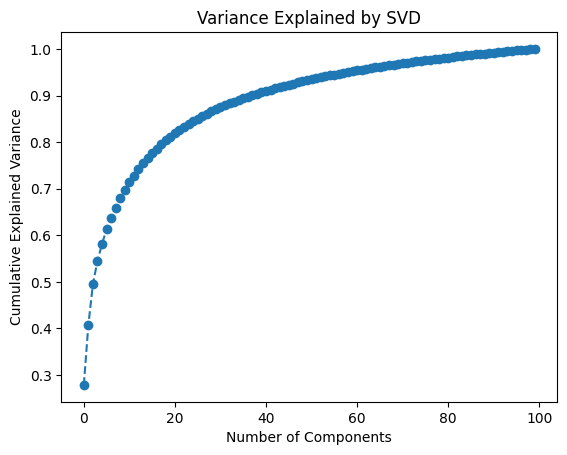

In [ ]:
explained_variance = (svd.singular_values_**2) / np.sum(svd.singular_values_**2)

plt.plot(np.cumsum(explained_variance), marker='o', linestyle='--')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Variance Explained by SVD")
plt.show()

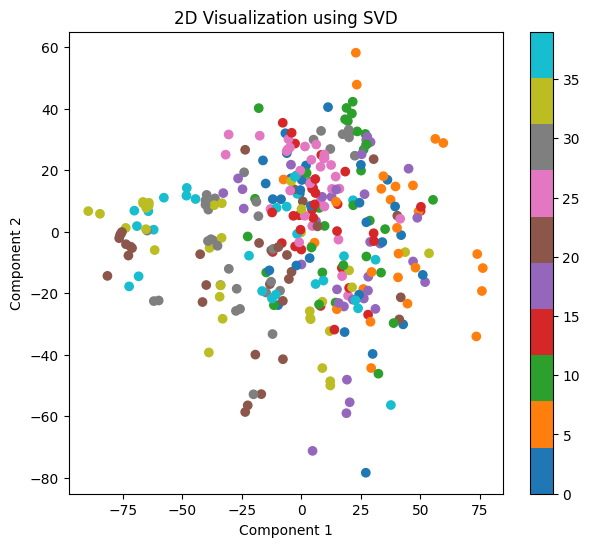

In [ ]:
X_2D = X_train_reduced[:, :2]

plt.figure(figsize=(7,6))
scatter = plt.scatter(X_2D[:,0], X_2D[:,1], c=y_train, cmap='tab10')

plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("2D Visualization using SVD")

plt.colorbar(scatter)
plt.show()

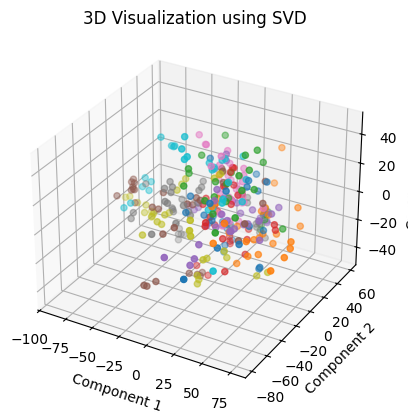

In [ ]:
X_3D = X_train_reduced[:, :3]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_3D[:,0], X_3D[:,1], X_3D[:,2], c=y_train, cmap='tab10')

ax.set_xlabel("Component 1")
ax.set_ylabel("Component 2")
ax.set_zlabel("Component 3")

plt.title("3D Visualization using SVD")
plt.show()